In [ ]:

import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astroquery.hips2fits import hips2fits
import numpy as np
import warnings
from matplotlib.colors import Normalize
from reproject import reproject_interp
from astropy.io import fits
import astropy.units as u
import plotfancy as pf
pf.housestyle_rcparams()

In [2]:
input_hdu = hips2fits.query(
            hips='CDS/P/DM/I/350/gaiaedr3',
            width=4096,
            height=2048,
            ra=0 * u.deg,
            dec=0 * u.deg,
            fov=360 * u.deg,
            projection='MOL',
            coordsys='galactic',
            format='fits'
        )

In [10]:
hdu = input_hdu[0]
wcs = WCS(hdu.header)
image_data = hdu.data.copy() 
image_data[np.isnan(image_data)] = 0  
with np.errstate(divide='ignore'):
    plot_data = np.log1p(image_data)  

vmin = np.percentile(plot_data[plot_data > 0], 1) 
vmax = np.percentile(plot_data, 99.5) 
norm = Normalize(vmin=vmin, vmax=vmax)

ny, nx = plot_data.shape  
pix_x, pix_y = np.meshgrid(np.arange(nx), np.arange(ny))   
world_coords = wcs.pixel_to_world(pix_x, pix_y) 
lon = world_coords.l.wrap_at(180 * u.deg).radian
lat = world_coords.b.radian

finite_mask = np.isfinite(lon) & np.isfinite(lat) 
lon = lon[finite_mask] 
lat = lat[finite_mask] 
plot_data_filtered = plot_data[finite_mask]  


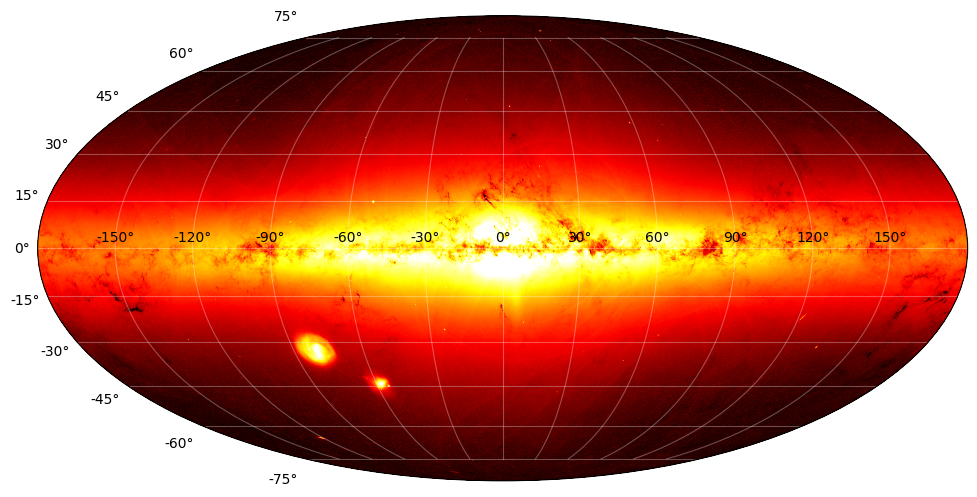

In [ ]:
fig = plt.figure(figsize=(8, 4)) 
ax = fig.add_subplot(111, projection='mollweide')  
im = ax.scatter(-lon, lat, c=plot_data_filtered, cmap='hot', norm=norm, s=0.1)  
ax.grid(True, color='white', ls='solid', alpha=0.7)  